In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
import xarray as xr
import numpy as np
import os
import warnings

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['font.size'] = 14

warnings.filterwarnings("ignore")

In [2]:
city = "JP-Yoy"
surf = "../data/URBAN_PLUMBER/input_files/{city}/surfdata_1x1_{city}_detailed_simyr2000_c230710.nc"
surf = xr.open_dataset(surf.format(city=city))
WTLUNIT_ROOF = surf["WTLUNIT_ROOF"].values.flatten()[2]
WTROAD_PERV = surf["WTROAD_PERV"].values.flatten()[2]

In [3]:
ds_list = []
ds_list_jja = []
p_dict = {
    'action_mode': [],
    'tg_threshold': [], 
    'water_tank_size': [],
}
outputpath='../data/water_tank_eval/'
ref_dsf = '/home/junjie/github/UrbSprIrr/data/workdir/outputfolder/lnd/hist/roofsp_raw.clm2.h0.2006-01-01-00000.nc'
ref_ds = xr.open_dataset(ref_dsf).sel(column=1,time = slice('2010', '2019'))
_ref_ds = xr.open_dataset(ref_dsf).sel(time = slice('2010', '2019')) 
ref_ds['QOVER'] = _ref_ds['QOVER'].sel(column=1)*WTLUNIT_ROOF + \
                  _ref_ds['QOVER'].sel(column=4)*(1-WTLUNIT_ROOF)*(1-WTROAD_PERV) + \
                  _ref_ds['QOVER'].sel(column=5)*(1-WTLUNIT_ROOF)*WTROAD_PERV

ref_ds['time'] = ref_ds['time'].dt.round('min') + np.timedelta64(9, 'h')    
ref_ds_jja = ref_ds.sel(time=(ref_ds['time.month']>=6) & (ref_ds['time.month']<=9))
for f in os.listdir(outputpath):
    f1 = outputpath + f
    ds = xr.open_dataset(f1).sel(column=1,time = slice('2010', '2019'))    
    _ds = xr.open_dataset(f1).sel(time = slice('2010', '2019')) 
    ds['QOVER'] = _ds['QOVER'].sel(column=1)*WTLUNIT_ROOF + \
                  _ds['QOVER'].sel(column=4)*(1-WTLUNIT_ROOF)*(1-WTROAD_PERV) + \
                  _ds['QOVER'].sel(column=5)*(1-WTLUNIT_ROOF)*WTROAD_PERV

    ds['time'] = ds['time'].dt.round('min') + np.timedelta64(9, 'h')
    exp0 = float(f.split('_')[2])
    exp1 = float(f.split('_')[3])
    exp2 = float(f.split('_')[4].split('.nc')[0])
    
    ds_list.append(ds)
    ds_list_jja.append(ds.sel(time=(ds['time.month']>=6) & (ds['time.month']<=9)))
    p_dict['action_mode'].append(exp0)
    p_dict['tg_threshold'].append(exp1)
    p_dict['water_tank_size'].append(exp2)
    
rwts_dict = {
    p_dict['water_tank_size'][i]: ds_list[i] for i in range(len(ds_list))
}
rwts_dict_jja = {
    p_dict['water_tank_size'][i]: ds_list_jja[i] for i in range(len(ds_list))
}

In [4]:
#ref_ds_extreme_QOVER = ref_ds['QOVER'].quantile(0.90, dim='time')*3600
ext = ref_ds_jja['QOVER']
ref_ds_extreme_QOVER = ext.where(ext>0).dropna('time').quantile(0.95, dim='time')*3600
ref_ds_extreme_QOVER

<xarray.DataArray 'QOVER' ()> Size: 8B
array(2.62568989)
Coordinates:
    quantile  float64 8B 0.95

In [5]:
print(len(ext.where(ext>ref_ds_extreme_QOVER/3600).dropna(dim='time'))*0.5)
e = rwts_dict_jja[1.0336860341880334]['QOVER']
print(len(e.where(e>ref_ds_extreme_QOVER/3600).dropna(dim='time'))*0.5)

594.5
589.5


In [6]:
#ref_ds_extreme_QOVER = ref_ds['QOVER'].quantile(0.90, dim='time')*3600
ext2 = ref_ds_jja['TG']
ref_ds_extreme_TG = ext2.where(ext2>0).quantile(0.95, dim='time') # 75% ~ 35 C
ref_ds_extreme_TG

<xarray.DataArray 'TG' ()> Size: 8B
array(326.68259583)
Coordinates:
    quantile  float64 8B 0.95

In [7]:
def get_plot_data(rwts_dict, ref_ds, X, var, ax):

    y = []
    ref = ref_ds[var].mean('time').values
    rwts = np.array(list(rwts_dict.keys()))
    rwts.sort()
    for w in rwts:
        rain = rwts_dict[w][var].mean('time')
        y.append(rain.values)
    
    y = np.array(y).flatten() - ref
    print(y)
    print(X)
    ax.scatter(x=X, y=y)        
    return X, y

def plot_extreme(rwts_dict, ref_ds, var, ax):
    colors = plt.get_cmap('Blues')(np.linspace(0, 1, len(rwts_dict)+2))
    rwts = np.array(list(rwts_dict.keys()))
    rwts.sort()
    i = 0
    ls_plot = []
    color = []
    RWT_size = []
    extrem = {
        "TG": ref_ds_extreme_TG,
        "TSA": 35 + 273.15,
        "HUMIDEX": 46,
        "QOVER": ref_ds_extreme_QOVER,
    }
    if var in ["QOVER"]:
        ref_ds[var] = ref_ds[var]*3600
    
    print(f"Extrem value for {var}: {extrem[var]}")
    data = ref_ds[var].where(ref_ds[var] > extrem[var]).dropna(dim='time')
    ls_plot.append(len(data)*0.5)
    color.append('#E02927')
    RWT_size.append(0)
    for w in rwts:
        #print(w)
        if var in ["QOVER"]:
            rwts_dict[w][var] = rwts_dict[w][var]*3600
        data = rwts_dict[w][var].where(rwts_dict[w][var] > extrem[var]).dropna(dim='time')
        ls_plot.append(len(data)*0.5)
        color.append(colors[i+2])
        RWT_size.append(w)
        i += 1

    #ax.bar(x=RWT_size, height=ls_plot, color=color, edgecolor='k', alpha=0.95, width=3)
    ax.scatter(x=RWT_size, y=ls_plot, color=color, edgecolor='k', alpha=0.95, s=200)
    # add text annotations of percentage
    ls_plot_per = [f"{(v-ls_plot[0]):.1f}" for v in ls_plot]
    for i, v in enumerate(ls_plot):
        #ax.text(RWT_size[i], v + 0.015*v, ls_plot_per[i], ha='center', color='black', fontsize=10) #for bar
        offset  = {
            'TG': 80,
            'TSA': 15,
            'HUMIDEX': 1.5,
            'QOVER': 2.5,
        }
        # TG的标签重叠在一起了 
        if var in ['TG']:
            ax.text(RWT_size[i], v + offset[var], ls_plot_per[i], ha='center', color='black', fontsize=10) #for scatter
        else:
            ax.text(RWT_size[i], v + offset[var], ls_plot_per[i], ha='center', color='black', fontsize=10) #for scatter
        lim = ax.get_ylim()
        offset2  = {
            'TG': 5,
            'TSA': 3.5,
            'HUMIDEX': 0.2,
            'QOVER': 0.3,
        }
        ax.set_ylim(lim[0], lim[1]+offset2[var])


Extrem value for TG: <xarray.DataArray 'TG' ()> Size: 8B
array(326.68259583)
Coordinates:
    quantile  float64 8B 0.95
Extrem value for TSA: 308.15
Extrem value for HUMIDEX: 46
Extrem value for QOVER: <xarray.DataArray 'QOVER' ()> Size: 8B
array(2.62568989)
Coordinates:
    quantile  float64 8B 0.95


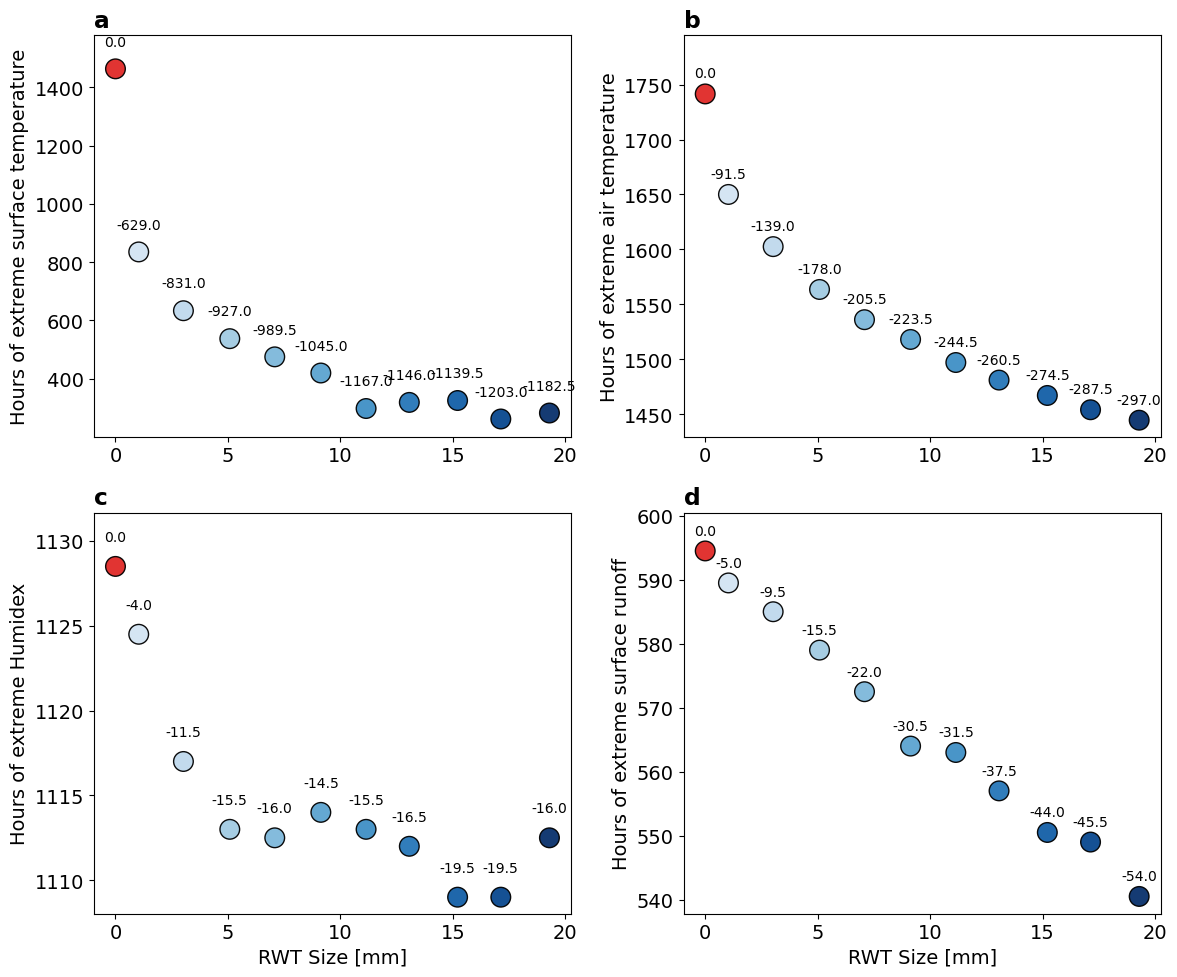

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs = axs.flatten()

vas = ['TG', 'TSA', 'HUMIDEX', 'QOVER']
titles = ['a', 'b', 'c', 'd']
ylabels = ['surface temperature', 'air temperature', 'Humidex', 'surface runoff']
i = 0
for ax in axs:
    #plot_profile(rwts_dict_jja, ref_ds_jja, vas[i], 'hour', ax)
    plot_extreme(rwts_dict_jja, ref_ds_jja, vas[i], ax)
    #plot_extreme(rwts_dict, ref_ds, vas[i], ax)
    title = f"Hours of extreme {ylabels[i]}"
    ax.set_title(titles[i], loc='left', fontweight='bold')
    ax.set_ylabel(title)
    
    if i in [2, 3]:
        ax.set_xlabel('RWT Size [mm]')
    else:
        ax.set_xlabel('')
    
    i += 1

fig.tight_layout()
plt.savefig('../data/figs/extreme_bar.pdf', bbox_inches='tight', dpi=300)